# Fine-Tuning des GBERT-Regressors mit Hybrid-MixUp

Dieses Notebook fine-tuned ein deutsches BERT-Modell (`deepset/gbert-base`) auf gemischten Alltagssprache- und Leichte-Sprache-Sätzen mittels des **Hybrid-MixUp-Verfahrens**.
Dabei wird ein zyklisches Lernthempo (Cyclic Learning Rate) verwendet, was die Stabilität der Regression verbessern soll.


In [1]:
import os
import sys

# Arbeitsverzeichnis auf das Root-Verzeichnis des Repositories setzen
while not os.path.exists(".git"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():  # System-Root erreicht, Abbruch
        break
    os.chdir("..")

print("Aktuelles Arbeitsverzeichnis:", os.getcwd())


Aktuelles Arbeitsverzeichnis: /home/fiete/master-thesis


In [2]:
import torch
print("CUDA verfügbar:", torch.cuda.is_available())
print("Device Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Keine GPU")

# Set seed for reproducibility
def set_seed(seed=42):
    import random
    import numpy as np
    import torch
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Globaler Seed auf {seed} gesetzt.")

set_seed(42)


CUDA verfügbar: True
Device Name: NVIDIA GeForce RTX 4090
Globaler Seed auf 42 gesetzt.


In [3]:
# ==============================================================================
# ZENTRALE KONFIGURATION & PARAMS (Hier anpassen)
# ==============================================================================
CSV_PATH = "data/analysis/information_loss_analysis_cleaned.csv"
LH_DATASET_PATH = "data/lebenshilfe/lebenshilfe_dataset_no_paragraphs.json"
MODEL_SAVE_PATH = "results/models/gbert_mixup_regression_hybrid_cyclic.pt"
MODEL_NAME = "deepset/gbert-base"

BATCH_SIZE = 16
EPOCHS = 15
LR = 2e-5
MAX_SIM = 0.98
MIN_SIM = 0.8
MAX_SEQ_LEN = 256


In [4]:
import pandas as pd
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import os
from transformers import BertTokenizerFast, BertModel

SEED = 42
set_seed(SEED)

# Daten laden
df = pd.read_csv(CSV_PATH)
mask = (df["semantic_similarity_8192"] >= MIN_SIM) & (df["semantic_similarity_8192"] <= MAX_SIM)
df_filtered = df[mask].dropna(subset=["ls_text", "as_text"])
print(f"Gefundene Artikelpaare: {len(df_filtered)}")

# Spacy für schnelles Satz-Splitting (Sentencizer) vorbereiten
nlp = spacy.blank("de")
nlp.add_pipe("sentencizer")

device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Nutze Device: {device}")


Globaler Seed auf 42 gesetzt.
Gefundene Artikelpaare: 1032
Nutze Device: cuda


## 2. Train-Val-Test Split


In [5]:
from sklearn.model_selection import train_test_split
import torch.optim as optim

train_val_df, test_df = train_test_split(df_filtered, test_size=0.1, random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.1111, random_state=42)
print(f"Training Artikelpaare: {len(train_df)}, Validierung Artikelpaare: {len(val_df)}, Test Artikelpaare: {len(test_df)}")


Training Artikelpaare: 824, Validierung Artikelpaare: 104, Test Artikelpaare: 104


## 3. Dataset-Klasse mit GBERT Tokenisierung und Hybrid-Cyclic-Augmentation

Der Hybrid Dataloader mischt dynamisch und statische Mischungen.


In [6]:
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

class MixupGBERTPyTorchDataset(Dataset):
    def __init__(self, df, tokenizer, nlp_sentencizer, max_seq_len=MAX_SEQ_LEN, mixtures_per_pair=20, is_train=True):
        self.tokenizer = tokenizer
        self.max_seq_len = max_seq_len
        self.is_train = is_train
        self.current_epoch = 0
        self.total_epochs = EPOCHS
        
        self.ls_data = []
        self.as_data = []
        self.static_samples = []
        
        # Seed festlegen für Konsistenz und Reproduzierbarkeit
        seed = 42 if is_train else 99
        set_seed(seed)
        
        for _, row in tqdm(df.iterrows(), total=len(df), desc="Segmentiere & Tokenisiere"):
            ls_doc = nlp_sentencizer(str(row["ls_text"])).sents
            as_doc = nlp_sentencizer(str(row["as_text"])).sents
            
            ls_sents = [s.text.strip() for s in ls_doc if s.text.strip()]
            as_sents = [s.text.strip() for s in as_doc if s.text.strip()]
            
            num_leicht = len(ls_sents)
            num_alltag = len(as_sents)
            
            if num_leicht == 0 or num_alltag == 0:
                continue
                
            self.ls_data.append(ls_sents)
            self.as_data.append(as_sents)
            
            article_idx = len(self.ls_data) - 1
            for _ in range(mixtures_per_pair):
                start_l, end_l = sorted([random.randint(0, num_leicht), random.randint(0, num_leicht)])
                sample_l = ls_sents[start_l:end_l]
                
                start_a, end_a = sorted([random.randint(0, num_alltag), random.randint(0, num_alltag)])
                sample_a = as_sents[start_a:end_a]
                
                if len(sample_l) == 0 and len(sample_a) == 0:
                    regression_target = 0.5
                    text = ""
                else:
                    char_len_l = sum(len(s) for s in sample_l)
                    char_len_a = sum(len(s) for s in sample_a)
                    total_char_len = char_len_l + char_len_a
                    regression_target = char_len_l / total_char_len if total_char_len > 0 else 0.5
                    
                    mixed_sentences = sample_l + sample_a
                    random.shuffle(mixed_sentences)
                    text = " ".join(mixed_sentences)
                    
                self.static_samples.append((article_idx, text, regression_target))
                
    def set_epoch(self, epoch, total_epochs):
        self.current_epoch = epoch
        self.total_epochs = total_epochs
            
    def __len__(self):
        return len(self.static_samples)
        
    def _tokenize_text(self, text):
        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_seq_len,
            padding="max_length",
            return_tensors="pt"
        )
        return encoding["input_ids"].squeeze(0), encoding["attention_mask"].squeeze(0)
        
    def __getitem__(self, idx):
        article_idx, static_text, static_target = self.static_samples[idx]
        
        if not self.is_train:
            ids, mask = self._tokenize_text(static_text)
            return ids, mask, torch.tensor(static_target, dtype=torch.float)
            
        p_dynamic = self.current_epoch / max(1, self.total_epochs - 1)
        
        if random.random() < p_dynamic:
            ls_sents = self.ls_data[article_idx]
            as_sents = self.as_data[article_idx]
            num_leicht = len(ls_sents)
            num_alltag = len(as_sents)
            
            start_l, end_l = sorted([random.randint(0, num_leicht), random.randint(0, num_leicht)])
            sample_l = ls_sents[start_l:end_l]
            
            start_a, end_a = sorted([random.randint(0, num_alltag), random.randint(0, num_alltag)])
            sample_a = as_sents[start_a:end_a]
            
            if len(sample_l) == 0 and len(sample_a) == 0:
                text = ""
                regression_target = 0.5
            else:
                char_len_l = sum(len(s) for s in sample_l)
                char_len_a = sum(len(s) for s in sample_a)
                total_char_len = char_len_l + char_len_a
                regression_target = char_len_l / total_char_len if total_char_len > 0 else 0.5
                
                mixed_sentences = sample_l + sample_a
                random.shuffle(mixed_sentences)
                text = " ".join(mixed_sentences)
                
            ids, mask = self._tokenize_text(text)
            return ids, mask, torch.tensor(regression_target, dtype=torch.float)
        else:
            ids, mask = self._tokenize_text(static_text)
            return ids, mask, torch.tensor(static_target, dtype=torch.float)

train_dataset = MixupGBERTPyTorchDataset(train_df, tokenizer, nlp, max_seq_len=MAX_SEQ_LEN, mixtures_per_pair=20, is_train=True)
val_dataset = MixupGBERTPyTorchDataset(val_df, tokenizer, nlp, max_seq_len=MAX_SEQ_LEN, mixtures_per_pair=20, is_train=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


/home/fiete/master-thesis/.venv/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Globaler Seed auf 42 gesetzt.


Segmentiere & Tokenisiere:   0%|          | 0/824 [00:00<?, ?it/s]

Globaler Seed auf 99 gesetzt.


Segmentiere & Tokenisiere:   0%|          | 0/104 [00:00<?, ?it/s]

## 4. Modelldefinition (GBERT Regressor)


In [7]:
class GBERTRegressor(nn.Module):
    def __init__(self, model_name=MODEL_NAME, dropout_rate=0.1):
        super(GBERTRegressor, self).__init__()
        self.gbert = BertModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout_rate)
        self.regressor = nn.Linear(self.gbert.config.hidden_size, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, input_ids, attention_mask):
        outputs = self.gbert(input_ids=input_ids, attention_mask=attention_mask)
        cls_rep = outputs.last_hidden_state[:, 0, :]
        dropped = self.dropout(cls_rep)
        logits = self.regressor(dropped)
        return self.sigmoid(logits)


## 5. Training mit Cyclic Learning Rate (Cosine Annealing)


In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

model = GBERTRegressor(MODEL_NAME).to(device)
optimizer = optim.AdamW(model.parameters(), lr=LR)
criterion = nn.MSELoss()

# Zyklischer Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=4, T_mult=1, eta_min=1e-6)

history = {'train_loss': [], 'val_loss': [], 'val_mae': []}
best_val_loss = float('inf')
patience = 5
counter = 0

for epoch in range(EPOCHS):
    train_dataset.set_epoch(epoch, EPOCHS)
    model.train()
    epoch_loss = 0.0
    for batch_x, batch_mask, batch_y in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
        batch_x, batch_mask, batch_y = batch_x.to(device), batch_mask.to(device), batch_y.to(device)
        optimizer.zero_grad()
        preds = model(batch_x, batch_mask).squeeze()
        if preds.ndim == 0:
            preds = preds.unsqueeze(0)
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch_x, batch_mask, batch_y in val_loader:
            batch_x, batch_mask, batch_y = batch_x.to(device), batch_mask.to(device), batch_y.to(device)
            preds = model(batch_x, batch_mask).squeeze()
            if preds.ndim == 0:
                preds = preds.unsqueeze(0)
            loss = criterion(preds, batch_y)
            val_loss += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())
            
    epoch_train_loss = epoch_loss / len(train_loader)
    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_mae = mean_absolute_error(all_targets, all_preds)
    
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['val_mae'].append(epoch_val_mae)
    
    print(f"Epoch {epoch+1:02d} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val MAE: {epoch_val_mae:.4f}")
    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"=> Modell gespeichert (bester Val Loss: {best_val_loss:.4f})")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early Stopping ausgelöst.")
            break
            
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Aktuelle Learning Rate: {current_lr:.6f}")


/home/fiete/master-thesis/.venv/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Epoch 1 [Train]:   0%|          | 0/1030 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.0185 | Val Loss: 0.0127 | Val MAE: 0.0773
=> Modell gespeichert (bester Val Loss: 0.0127)
Aktuelle Learning Rate: 0.000017


Epoch 2 [Train]:   0%|          | 0/1030 [00:00<?, ?it/s]

Epoch 02 | Train Loss: 0.0067 | Val Loss: 0.0096 | Val MAE: 0.0633
=> Modell gespeichert (bester Val Loss: 0.0096)
Aktuelle Learning Rate: 0.000011


...

Epoch 13 | Train Loss: 0.0023 | Val Loss: 0.0051 | Val MAE: 0.0353
=> Modell gespeichert (bester Val Loss: 0.0051)
Aktuelle Learning Rate: 0.000017


Epoch 14 [Train]:   0%|          | 0/1030 [00:00<?, ?it/s]

Epoch 14 | Train Loss: 0.0026 | Val Loss: 0.0052 | Val MAE: 0.0352
Aktuelle Learning Rate: 0.000011


Epoch 15 [Train]:   0%|          | 0/1030 [00:00<?, ?it/s]

Epoch 15 | Train Loss: 0.0021 | Val Loss: 0.0050 | Val MAE: 0.0341
=> Modell gespeichert (bester Val Loss: 0.0050)
Aktuelle Learning Rate: 0.000004


## 6. Visualisierungen


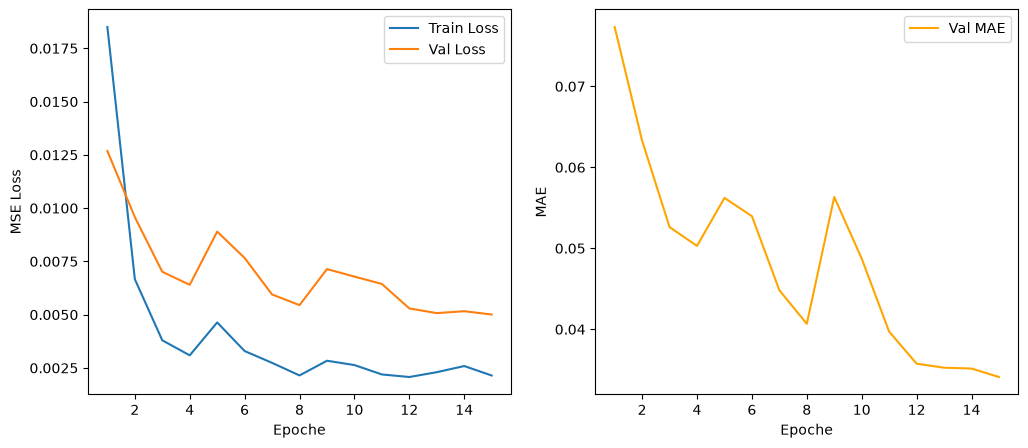

In [9]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(history['train_loss'])+1), history['train_loss'], label='Train Loss')
plt.plot(range(1, len(history['val_loss'])+1), history['val_loss'], label='Val Loss')
plt.xlabel('Epoche')
plt.ylabel('MSE Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(history['val_mae'])+1), history['val_mae'], label='Val MAE', color='orange')
plt.xlabel('Epoche')
plt.ylabel('MAE')
plt.legend()
plt.show()


## 7. Out-of-Domain Evaluation auf Lebenshilfe-Datensatz


In [10]:
import json
from scipy.stats import pearsonr, spearmanr

# Bestes Modell laden
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model.eval()

with open(LH_DATASET_PATH, "r", encoding="utf-8") as f:
    lh_data = json.load(f)
print(f"Anzahl geladener Lebenshilfe Artikelpaare: {len(lh_data)}")
lh_df = pd.DataFrame(lh_data)

def text_to_gbert_chunks(text, tokenizer, max_len=MAX_SEQ_LEN):
    doc = nlp(text)
    chunks = []
    current_chunk = []
    current_len = 0
    for sent in doc.sents:
        sent_text = sent.text.strip()
        if not sent_text:
            continue
        tokens = tokenizer.tokenize(sent_text)
        if len(tokens) == 0:
            continue
        if current_len + len(tokens) + 2 > max_len:
            if current_chunk:
                chunks.append(" ".join(current_chunk))
            current_chunk = [sent_text]
            current_len = len(tokens)
        else:
            current_chunk.append(sent_text)
            current_len += len(tokens)
    if current_chunk:
        chunks.append(" ".join(current_chunk))
        
    encoded_list = []
    for chunk in chunks:
        enc = tokenizer(chunk, truncation=True, max_length=max_len, padding="max_length", return_tensors="pt")
        encoded_list.append(enc)
    return encoded_list

lh_results = {"ls_preds": [], "as_preds": []}

for _, row in tqdm(lh_df.iterrows(), total=len(lh_df), desc="LH Eval"):
    ls_text = str(row.get("ls_text", ""))
    as_text = str(row.get("as_text", ""))
    
    # LS (Einfache Sprache)
    ls_chunks = text_to_gbert_chunks(ls_text, tokenizer)
    for chunk in ls_chunks:
        input_ids = chunk["input_ids"].to(device)
        attention_mask = chunk["attention_mask"].to(device)
        with torch.no_grad():
            preds = model(input_ids, attention_mask).squeeze().cpu().numpy()
            if preds.ndim == 0:
                preds = np.array([preds])
            lh_results["ls_preds"].extend(preds)
            
    # AS (Alltagssprache)
    as_chunks = text_to_gbert_chunks(as_text, tokenizer)
    for chunk in as_chunks:
        input_ids = chunk["input_ids"].to(device)
        attention_mask = chunk["attention_mask"].to(device)
        with torch.no_grad():
            preds = model(input_ids, attention_mask).squeeze().cpu().numpy()
            if preds.ndim == 0:
                preds = np.array([preds])
            lh_results["as_preds"].extend(preds)

ls_p = lh_results["ls_preds"]
as_p = lh_results["as_preds"]

mean_ls = np.mean(ls_p)
mean_as = np.mean(as_p)

correct_ls = sum(1 for p in ls_p if p > 0.5)
correct_as = sum(1 for p in as_p if p <= 0.5)

acc = (correct_ls + correct_as) / (len(ls_p) + len(as_p))
bacc_ls = correct_ls / len(ls_p)
bacc_as = correct_as / len(as_p)
bacc = (bacc_ls + bacc_as) / 2
mae = (sum(1.0 - p for p in ls_p) + sum(p for p in as_p)) / (len(ls_p) + len(as_p))

print(f"Anzahl LS-Chunks: {len(ls_p)}, Anzahl AS-Chunks: {len(as_p)}")
print(f"Ø Lambda (LS): {mean_ls:.4f}")
print(f"Ø Lambda (AS): {mean_as:.4f}")
print(f"Accuracy (Schwelle 0.5): {acc*100:.2f}%")
print(f"Balanced Acc: {bacc*100:.2f}%")
print(f"MAE (Target 1/0): {mae:.4f}")


Anzahl geladener Lebenshilfe Artikelpaare: 49


LH Eval:   0%|          | 0/49 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (552 > 512). Running this sequence through the model will result in indexing errors


Anzahl LS-Chunks: 361, Anzahl AS-Chunks: 245
Ø Lambda (LS): 0.8598
Ø Lambda (AS): 0.0564
Accuracy (Schwelle 0.5): 95.38%
Balanced Acc: 95.60%
MAE (Target 1/0): 0.1063
